<center><img src='./Figs/cs-logo.png' width=200></center>



<h6><center></center></h6>

<h1>
<hr style=" border:none; height:3px;">
<center> Mention IA - CentraleSupélec - VISORD  </center>
<h3><center>Student: EL BARHICHI Mohammed</center></h3>
<hr style=" border:none; height:3px;">
</h1>

# Un détecteur d'objets (face recognition)

Dans cette partie, vous allez mettre en œuvre une version simplifiée du processus de détection des objets.


### Représentation HOG

Dans cette section, vous allez calculer la représentation HOG moyenne de visages humains.
Il y a 31 images de visages alignés fournies dans le dossier [face](./face). Elles sont toutes alignées et ont la même taille. Nous allons obtenir un visage moyen à partir de ces images et calculer une représentation de la caractéristique de HOG pour le visage moyen.

Quels éléments sur ce type de descripteurs : 
 + HOG se concentre sur la structure de l'objet. Il extrait l'information de la magnitude des contours ainsi que l'orientation des contours ou bords.
 + Il utilise une fenêtre de détection de $64 \times 128$ pixels, l'image est donc d'abord convertie en forme $(64, 128)$.
 + L'image est ensuite divisée en petites parties, puis le gradient et l'orientation de chaque partie sont calculés. Elle est divisée en blocs de $8 \times 16$ cellules avec un chevauchement de $50\%$, il y aura donc $7 \times 15 = 105$ blocs au total, et chaque bloc est constitué de $2 \times 2$ cellules de $8 \times 8$ pixels.
 
Pour la construction du vecteur de caractéristiques , nous prenons 64 vecteurs de gradient de chaque bloc (cellule de 8x8 pixels) et les mettons dans un histogramme à 9 cases.

Pour une description plus détaillée de ce type de représentation, l'article original de Dalal and Triggs est disponible [ici](https://lear.inrialpes.fr/people/triggs/pubs/Dalal-cvpr05.pdf)

Ici, il est demandé de faire une fonction permettant de calculer et de visualiser les descripeurs HOG pour une image donnée. Vous pourrez par exemple utiliser `hog_feature` de la bibliothèque `scikit-image` dans laquelle une fonction pré-définie [`hog`](https://scikit-image.org/docs/dev/api/skimage.feature.html#hog) est implémentée. Vous pouvez librement vous inspirer de la documentation associée [ici](https://scikit-image.org/docs/dev/auto_examples/features_detection/plot_hog.html).

Une fonction est aussi disponible dans [OpenCV](https://www.programcreek.com/python/example/84776/cv2.HOGDescriptor), mais elle est beaucoup moins documentée. Vous êtes libres d'utiliser celle que vous souhaitez.



In [ ]:
from skimage.feature import hog
from skimage import color, exposure

def hog_feature(image, pixel_per_cell=8):
    """
    Compute HOG feature for a given image.
    Important:
    - Use the hog function provided by skimage to generate both the
      feature vector and the visualization image.
    - For the block normalization parameter, use L1.
    Args:
        image: an image with the object that we want to detect.
        pixel_per_cell: number of pixels in each cell, an argument for hog descriptor.
    Returns:
        hog_feature: a vector of hog representation.
        hog_image: an image representation of hog provided by skimage.
    """
    # Convert image to grayscale
    if len(image.shape) > 2:
        image = color.rgb2gray(image)

    # Calculate the HOG descriptor and visualization image
    hog_feature, hog_image = hog(
        image, 
        orientations=9,                       # Histogram with 9 bins (orientations)
        pixels_per_cell=(pixel_per_cell, pixel_per_cell),  # Pixel per cell
        cells_per_block=(2, 2),               # Cells per block
        block_norm='L1',                      # Block normalization
        visualize=True,                       # Generate visualization
        feature_vector=True                   # Return data as feature vector
    )

    # Enhance the hog_image visualization for better contrast
    hog_image = exposure.rescale_intensity(hog_image, in_range=(0, 10))

    return hog_feature, hog_image



Tester votre fonction.

HOG feature vector shape: (19656,)


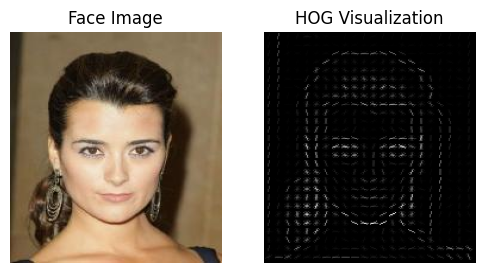

In [ ]:
import os
from skimage import io
from skimage.transform import resize

face_folder = '.\\face'
face_files = [os.path.join(face_folder, f) for f in os.listdir(face_folder)
              if f.lower().endswith(('.jpg'))]

test_image = io.imread(face_files[-1])

hog_vec, hog_vis = hog_feature(test_image, pixel_per_cell=8)

print("HOG feature vector shape:", hog_vec.shape)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(test_image, cmap='gray', aspect='auto')
plt.title('Face Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hog_vis, cmap='gray', aspect='auto')
plt.title('HOG Visualization')
plt.axis('off')

plt.show()

###  BONUS 
Si vous avez du temps, vous pouvez aussi proposer votre propre implémentation de HOG (documentation [ici](https://learnopencv.com/histogram-of-oriented-gradients/))


In [ ]:
import numpy as np
import cv2
import math

def custom_hog_face(image, cell_size=8, block_size=2, nbins=9, eps=1e-5, visualize=False):
    """
    Compute a tailored HOG descriptor specifically for aligned face images
    of size 64x128. The image is assumed to be grayscale (if not, it is converted).
    
    Parameters:
    -----------
    image : ndarray
        Input image. If color, it is converted to grayscale using skimage.color.rgb2gray.
    cell_size : int, default=8
        Size (in pixels) of each cell (cells are cell_size x cell_size).
    block_size : int, default=2
        Number of cells per block (block is block_size x block_size).
    nbins : int, default=9
        Number of orientation bins (covering 0°–180°, so each bin spans 20°).
    eps : float, default=1e-5
        Small constant added for numerical stability in normalization.
    visualize : bool, default=False
        If True, return a visualization image that draws the dominant gradient
        orientation per cell.
    
    Returns:
    --------
    hog_descriptor : 1D ndarray
        Concatenated descriptor from all overlapping blocks.
    hog_vis : 2D ndarray or None
        If visualize is True, a visualization image with lines in cells
        representing dominant orientations; otherwise None.
    
    Notes:
    ------
    - This implementation is streamlined for aligned face images.
    - It uses central differences (via OpenCV’s Sobel) for gradient computation.
    - Each cell’s histogram is filled using bilinear orientation interpolation.
    - Each block (2x2 cells, i.e. 36 values) is normalized using the L1 norm.
    """
    # Convert to grayscale
    if image.ndim == 3:
        image = color.rgb2gray(image)
    # Ensure image is float32.
    image = np.asarray(image, dtype=np.float32)
    
    # Compute gradients using Sobel operators.
    gx = cv2.Sobel(image, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(image, cv2.CV_32F, 0, 1, ksize=3)
    magnitude = np.sqrt(gx**2 + gy**2)
    # Compute orientation in degrees (0 to 180)
    orientation = (np.rad2deg(np.arctan2(gy, gx)) % 180)
    
    # Expected dimensions:
    height, width = image.shape  # Should be 64x128
    n_cells_y = height // cell_size  # 64/8 = 8
    n_cells_x = width // cell_size   # 128/8 = 16
    
    # Initialize cell histograms: shape (n_cells_y, n_cells_x, nbins)
    cell_hist = np.zeros((n_cells_y, n_cells_x, nbins), dtype=np.float32)
    bin_width = 180.0 / nbins  # e.g., 20 degrees per bin
    
    # Populate cell histograms with bilinear interpolation on the orientation axis.
    for i in range(n_cells_y):
        for j in range(n_cells_x):
            # Define cell boundaries.
            cell_mag = magnitude[i*cell_size:(i+1)*cell_size, j*cell_size:(j+1)*cell_size]
            cell_ori = orientation[i*cell_size:(i+1)*cell_size, j*cell_size:(j+1)*cell_size]
            # Loop through each pixel within the cell.
            for y in range(cell_mag.shape[0]):
                for x in range(cell_mag.shape[1]):
                    mag = cell_mag[y, x]
                    ang = cell_ori[y, x]
                    # Determine lower bin index.
                    bin_idx = int(ang // bin_width)
                    # Fractional contribution to next bin.
                    frac = (ang - (bin_idx * bin_width)) / bin_width
                    next_bin = (bin_idx + 1) % nbins
                    # Distribute magnitude between the two bins.
                    cell_hist[i, j, bin_idx] += mag * (1 - frac)
                    cell_hist[i, j, next_bin] += mag * frac
    
    # Normalize blocks (overlapping, stride=1 cell).
    n_blocks_y = n_cells_y - block_size + 1
    n_blocks_x = n_cells_x - block_size + 1
    hog_descriptor = []
    for i in range(n_blocks_y):
        for j in range(n_blocks_x):
            # Extract a block: 2x2 cells => 36 values.
            block = cell_hist[i:i+block_size, j:j+block_size, :].ravel()
            # L1 normalization.
            norm = np.sum(np.abs(block)) + eps
            block_norm = block / norm
            hog_descriptor.append(block_norm)
    hog_descriptor = np.concatenate(hog_descriptor)
    
    # Create visualization image if requested.
    hog_vis = None
    if visualize:
        hog_vis = np.zeros((height, width), dtype=np.float32)
        # For each cell, draw a line in the direction of the dominant bin.
        for i in range(n_cells_y):
            for j in range(n_cells_x):
                cell_histogram = cell_hist[i, j, :]
                dominant_bin = np.argmax(cell_histogram)
                # Compute bin center angle.
                angle_deg = (dominant_bin + 0.5) * bin_width
                angle_rad = math.radians(angle_deg)
                # Calculate cell center.
                center_y = int(i * cell_size + cell_size / 2)
                center_x = int(j * cell_size + cell_size / 2)
                # Line length is half the cell size.
                line_length = cell_size // 2
                dx = int(line_length * math.cos(angle_rad))
                dy = int(line_length * math.sin(angle_rad))
                pt1 = (center_x - dx, center_y - dy)
                pt2 = (center_x + dx, center_y + dy)
                cv2.line(hog_vis, pt1, pt2, color=255, thickness=1)
        # Normalize visualization to range [0,1].
        hog_vis = (hog_vis - np.min(hog_vis)) / (np.max(hog_vis) - np.min(hog_vis) + eps)
    
    return hog_feature(image)


Let's test it

HOG feature vector shape: (3780,)


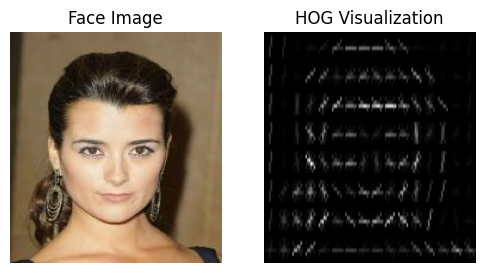

In [ ]:
import os
from skimage import io
from skimage.transform import resize

face_folder = '.\\face'
face_files = [os.path.join(face_folder, f) for f in os.listdir(face_folder)
              if f.lower().endswith(('.jpg'))]

test_image = io.imread(face_files[-1])
test_image_resized = resize(test_image, (64, 128), anti_aliasing=True)

hog_vec, hog_vis = custom_hog_face(
    test_image_resized,
    cell_size=8,
    block_size=2,
    nbins=9,
    visualize=True
)

print("HOG feature vector shape:", hog_vec.shape)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(test_image, cmap='gray', aspect='auto')
plt.title('Face Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hog_vis, cmap='gray', aspect='auto')
plt.title('HOG Visualization')
plt.axis('off')

plt.show()

**Comment:**

The custom implementation of the Histogram of Oriented Gradients (HOG) descriptor, specifically designed for our aligned facial images of size 64×128, provides acceptable results in terms of the robustness of gradient representation and orientation.

However, it should be noted that the visualization produced by our implementation is not as refined or visually “light” as that generated by the built-in function in scikit-image.

This difference can be attributed to the optimizations and fine-tuning (e.g., advanced bilinear interpolation, specific normalization choices, etc.) integrated into the built-in version, enabling a more elegant visual representation.

For our project, the quality of the HOG vector (used for detection/recognition) remains satisfactory, even if the visualization can be improved compared to the standard version.

### FIN BONUS

### Obtention d' un visage moyen
Ecrire une fonction permettant d'obtenir un visage moyen à partir de l'ensemble des images de visages (moyenne des images)


In [ ]:
def compute_mean_face(face_folder):
    """
    Loads all face images from the specified folder, resizes them to the given image_size,
    and computes the mean face by taking the pixel-wise average.
    
    Parameters:
        face_folder : str
            Path to the folder containing face images.
    
    Returns:
        mean_face : ndarray
            The mean face image (float values in [0,1]).
    """
    face_files = [os.path.join(face_folder, f) for f in os.listdir(face_folder)
                  if f.lower().endswith(('.jpg'))]
    
    faces = []
    for filepath in face_files:
        img = io.imread(filepath)
        # Convert to grayscale
        if img.ndim == 3:
            img = color.rgb2gray(img)
        faces.append(img)
    
    faces = np.array(faces)
    mean_face = np.mean(faces, axis=0)
    return mean_face


Let's see what is the average face in the given folder

Mean face computed. Shape: (218, 178)


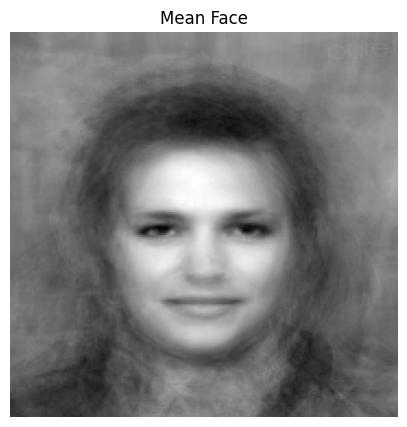

In [67]:
# Compute the mean face from the folder.
mean_face = compute_mean_face(face_folder)
print("Mean face computed. Shape:", mean_face.shape)

# Visualize the mean face.
plt.figure(figsize=(5, 5))
plt.imshow(mean_face, cmap='gray', aspect='auto')
plt.title("Mean Face")
plt.axis("off")
plt.show()

###  Modèle de visage

Calculer une représentation de la caractéristique de HOG pour le visage moyen. Ce sera votre modèle de visage.

In [70]:
def compute_face_model(face_folder):
    """
    Computes the mean face from the given folder of aligned face images and 
    computes the HOG descriptor for that mean face, which serves as the face model.
    
    Parameters:
        face_folder : str
            Path to the folder containing face images.
        pixel_per_cell : int
            The number of pixels per cell for the HOG computation.
    
    Returns:
        mean_face : ndarray
            The computed mean face image.
        face_model : ndarray
            The HOG feature vector of the mean face.
        hog_vis : ndarray or None
            A visualization image of the HOG descriptor for the mean face.
    """
    # Step 1: Compute the mean face.
    mean_face = compute_mean_face(face_folder)
    
    # Step 2: Compute the HOG descriptor for the mean face.
    # Here we use the predefined hog_feature,
    hog_vector, hog_vis = hog_feature(mean_face)
    
    return mean_face, hog_vector, hog_vis

Let's now see the HOG caracteristics of the average face

Face model (HOG feature vector) shape: (19656,)


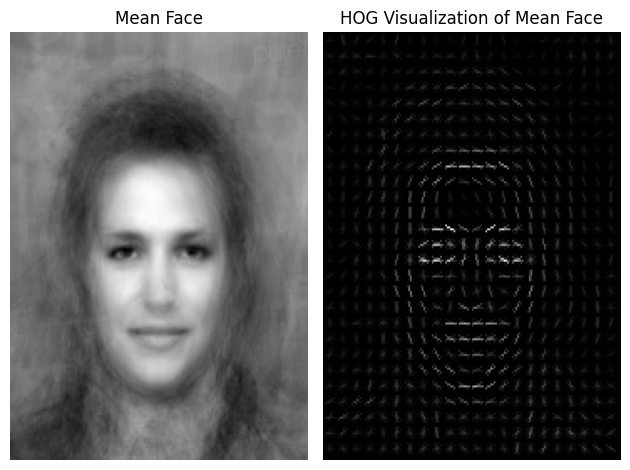

In [72]:
mean_face, face_model, hog_vis = compute_face_model(face_folder)
print("Face model (HOG feature vector) shape:", face_model.shape)

# Display the mean face and HOG visualization.
plt.figure()

plt.subplot(1, 2, 1)
plt.imshow(mean_face, cmap='gray', aspect='auto')
plt.title("Mean Face")
plt.axis("off")

plt.subplot(1, 2, 2)
if hog_vis is not None:
    plt.imshow(hog_vis, cmap='gray', aspect='auto') 
    plt.title("HOG Visualization of Mean Face")
plt.axis("off")

plt.tight_layout()
plt.show()

### Fenêtre glissante

Implémentez la fonction **`sliding_window`** qui permet de faire glisser des fenêtres sur une image avec une taille de fenêtre spécifique. La fenêtre glisse sur l'image et vérifie si un objet est détecté avec un score de similarité élevé avec le modèle à chaque emplacement. Nous calculons ces scores comme le produit scalaire des caractéristiques HoG du modèle et des caractéristiques HoG de chaque fenêtre lorsque les fenêtres glissent sur l'image. Ces scores généreront une carte de réponse et vous pourrez trouver l'emplacement de la fenêtre ayant le score HoG le plus élevé.

Indication : il sera peut être utile de changer l'échelle de l'image

In [ ]:
from skimage import feature
import matplotlib.patches as patches


def sliding_window(image, template_feature, step_size, window_size, pixel_per_cell=8,
                   return_unresized_response=False, debug=False, debug_positions=None, debug_score=17):
    """
    A sliding window that checks each different location in the image,
    and finds which location has the highest hog score. The hog score is
    computed as the dot product between the hog feature of the sliding window
    and the hog feature of the template. It generates a response map where
    each location of the response map is a corresponding score. And you will
    need to resize the response map so that it has the same shape as the image.

    Args:
        image: np array of size (h,w). The image to apply sliding window.
        template_feature:  an array of size (m,).
            The hog representation of the object you want to find.
        step_size: int of the step size to move the window.
        window_size: pair of ints that is the height and width of the window.
        return_unresized_response: a bool to indicate returning unresized response.
            Your code can always leave this as default.

        to debug:
            debug: a bool to indicate if you want to visualize the sliding window.
                Your code can always leave this as default.
            debug_positions: a list of tuples (r,c) that are the positions you want
                to visualize the sliding window. This is only used when debug is True.
            debug_score: a float indicating the score threshold to visualize the sliding window.
                This is only used when debug is True.
                
    Returns:
        max_score: float of the highest hog score.
        maxr: int of row where the max_score is found (top-left of window).
        maxc: int of column where the max_score is found (top-left of window).
        response_map: an np array of size (ceil H / step_size, ceil W / step_size).
        response_map_resized: an np array of size (h,w).
    """
    winH, winW = window_size
    H, W = image.shape
    pad_image = np.lib.pad(
        image,
        ((winH // 2,
          winH - winH // 2),
         (winW // 2,
          winW - winW // 2)),
        mode='constant')

    (max_score, maxr, maxc) = (-np.inf, 0, 0)
    response_map = np.zeros((math.ceil(H / step_size), math.ceil(W / step_size)))
    response_map_resized = np.zeros(image.shape)

    for idx_r, r in enumerate(range(0, H, step_size)):
        for idx_c, c in enumerate(range(0, W, step_size)):
            window = pad_image[r : r + winH, c : c + winW]
            
            window_hog, _ = hog_feature(window, pixel_per_cell=pixel_per_cell)
            
            score = np.dot(window_hog, template_feature)
            
            response_map[idx_r, idx_c] = score
            
            if debug :
                if (debug_positions is not None and (idx_c, idx_r) in debug_positions) or score > debug_score:
                    fig, ax = plt.subplots()
                    ax.imshow(image, cmap='gray')
                    # Note: (c, r) is used because c is the x-coordinate, and r is the y-coordinate.
                    rect = patches.Rectangle((c - winW/2, r - winH/2), winW, winH,
                            edgecolor='red', facecolor='none', linewidth=2)
                    ax.add_patch(rect)
                    plt.title(f"Window at (r={r}, c={c}) with score {score:.2f}")
                    plt.axis('off')
                    plt.show()
            

            if score > max_score:
                max_score = score
                maxr = r
                maxc = c


    # Resize the response map so that it matches the original image shape.
    response_map_resized = resize(response_map, image.shape, mode='constant')

    if return_unresized_response:
        return (max_score, maxr, maxc, response_map_resized, response_map)
    else:
        return (max_score, maxr, maxc, response_map_resized)

 Tester votre fonction sur l'image ci-dessous avec un changement d'échelle de $0.8$ puis de $1.2$.

We will see the scores obtained for each window on the test image without rescaling first to uderstand the problem.

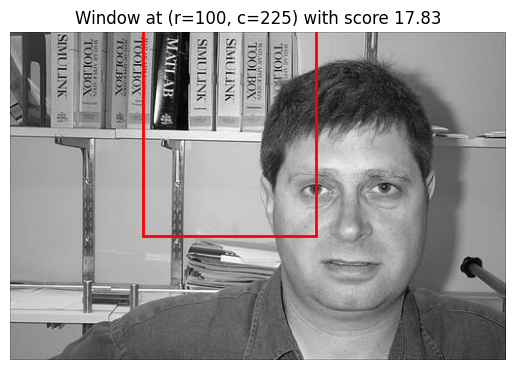

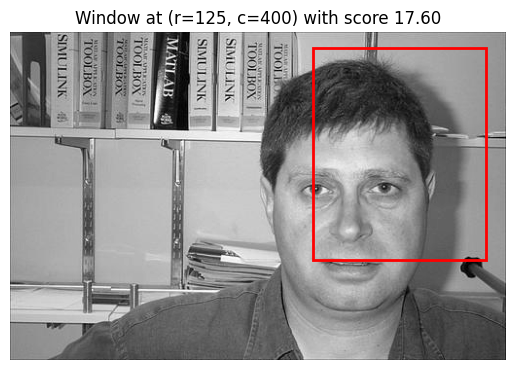

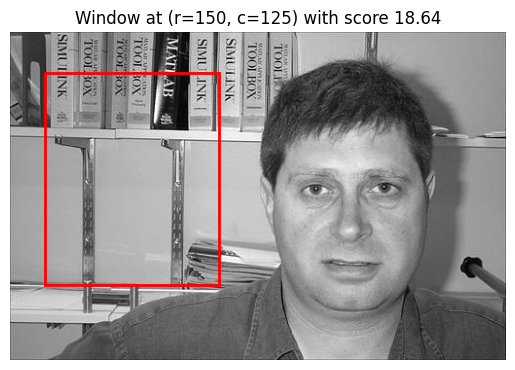

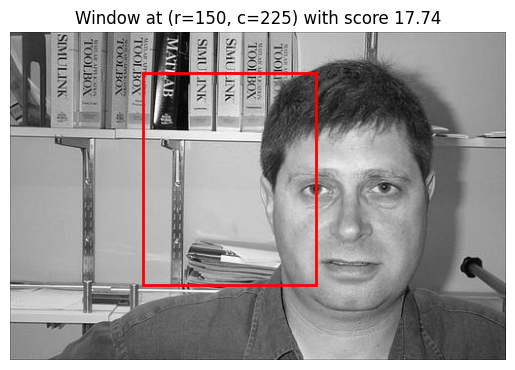

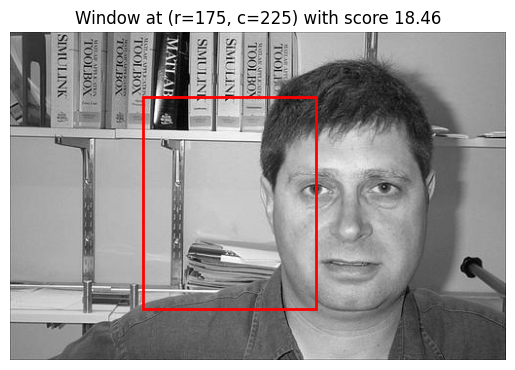

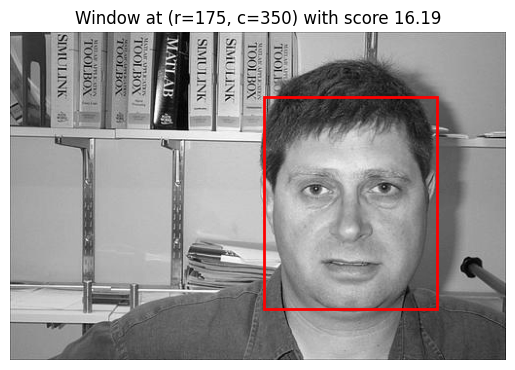

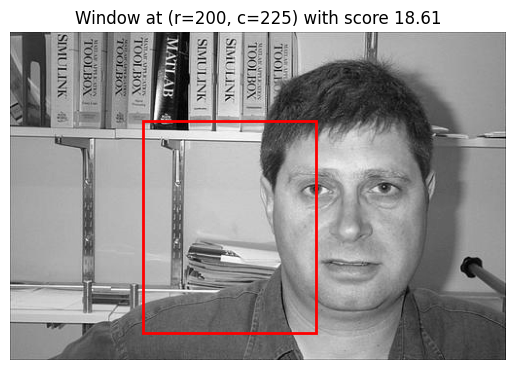

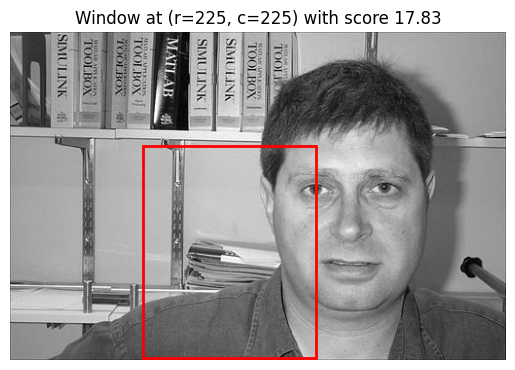

In [138]:
face_folder = './face'

_, template_feature, _ = compute_face_model(face_folder)

image_path = 'image_0001.jpg'  
test_image = io.imread(image_path)

if test_image.ndim == 3:
    test_image = color.rgb2gray(test_image)

window_size = (218, 178)
step_size = 25

max_score, maxr, maxc, response_map_resized, response_map = sliding_window(
        test_image,
        template_feature,
        step_size,
        window_size,
        pixel_per_cell=8,
        debug=True,
        debug_positions=[(14, 7)],
        debug_score=17.5,  
        return_unresized_response=True
    )

After testing on the original scale (scale factor 1), We observed that the sliding window did not yield a high score when centered on the person's face—the score was 16,19. Interestingly, some non-face regions, such as areas with books, produced even higher scores (up to 18.64). This suggests that, at scale 1, the fixed window size (derived from the mean face) may not align well with the actual scale of the face in the test image. In other words, the relative size and position of the face within the window differ from that in the average (template) face. This discrepancy indicates that using a single scale is not optimal for detection across images with varying object sizes. Therefore, experimenting with different rescaling factors—such as scaling the image to 0.8 and 1.2—should help adjust the window to better match the true size of the face, improving detection accuracy.

Let's now test with a step_size of 8 to have more sliding windows

Maximum score: 19.1186998723836
Location of max score (row, col): 152 128


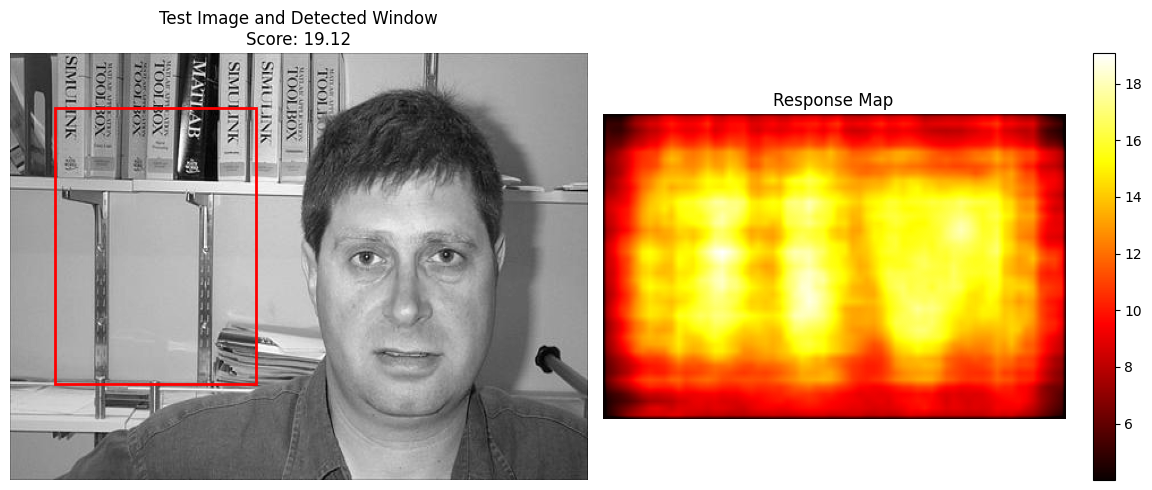

In [ ]:
step_size = 8

max_score, maxr, maxc, response_map_resized = sliding_window(
        test_image,
        template_feature,
        step_size,
        window_size,
        pixel_per_cell=8,
        debug=False,
    )
    
print("Maximum score:", max_score)
print("Location of max score (row, col):", maxr, maxc)

# Create rectangle patch for the detected window.
rect = patches.Rectangle((maxc - window_size[1] / 2, maxr - window_size[0] / 2),
                          window_size[1], window_size[0],
                          edgecolor='red', facecolor='none', linewidth=2)

# Visualize the scaled image and the corresponding resized response map.
plt.figure(figsize=(12, 5)) 


ax = plt.subplot(1, 2, 1)
plt.imshow(test_image, cmap='gray', aspect='auto')
ax.add_patch(rect) 
plt.title(f"Test Image and Detected Window\nScore: {max_score:.2f}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(response_map_resized, cmap='hot')
plt.title("Response Map")
plt.colorbar()
plt.axis("off")

plt.tight_layout()
plt.show()


It is still giving the area of the books as the best match. Let's now see the influence of the scale

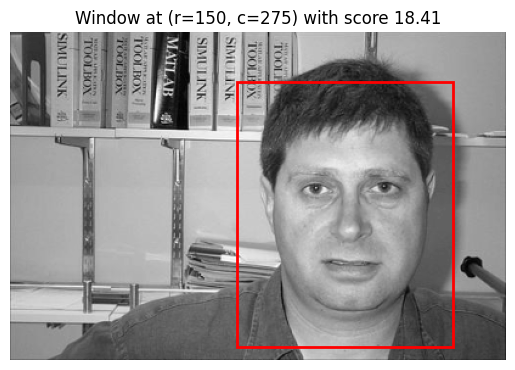

In [155]:
from skimage.transform import rescale

scale = 0.8

scaled_image = rescale(test_image, scale, anti_aliasing=True)



step_size = 25
max_score, maxr, maxc, response_map_resized = sliding_window(
        scaled_image,
        template_feature,
        step_size,
        window_size,
        pixel_per_cell=8,
        debug=True,
        debug_score=18,
    )

Maximum score: 18.409118377207516
Location of max score (row, col): 150 275


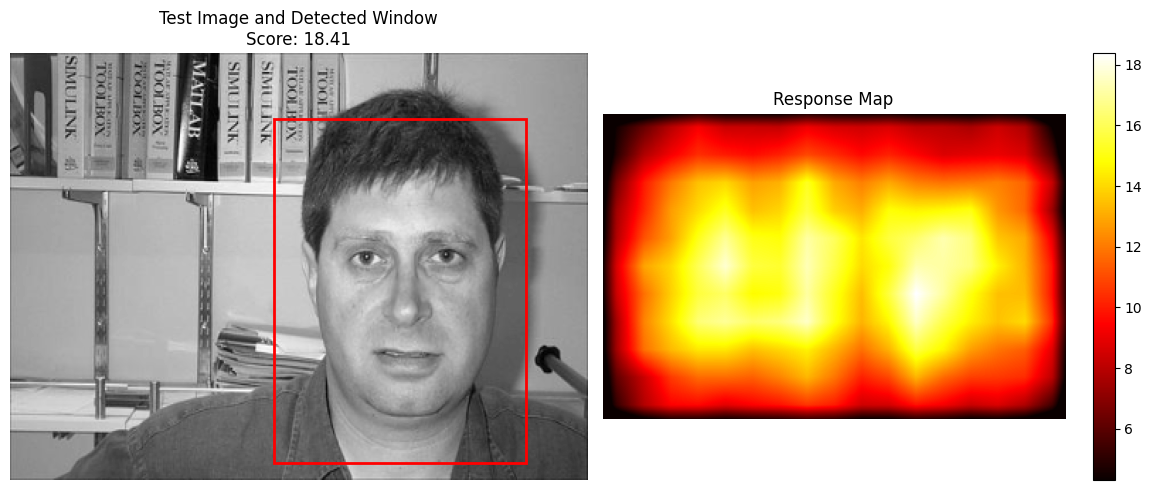

In [ ]:
print("Maximum score:", max_score)
print("Location of max score (row, col):", maxr, maxc)
rect = patches.Rectangle((maxc - (window_size[1]) / 2, maxr - (window_size[0] ) / 2),
                          window_size[1], window_size[0],
                          edgecolor='red', facecolor='none', linewidth=2)

# Visualize the scaled image and the corresponding resized response map.
plt.figure(figsize=(12, 5)) 

ax = plt.subplot(1, 2, 1)
plt.imshow(scaled_image, cmap='gray', aspect='auto')
ax.add_patch(rect) 
plt.title(f"Test Image and Detected Window\nScore: {max_score:.2f}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(response_map_resized, cmap='hot')
plt.title("Response Map")
plt.colorbar()
plt.axis("off")

plt.tight_layout()
plt.show()


Now let's test the scale of 1.2

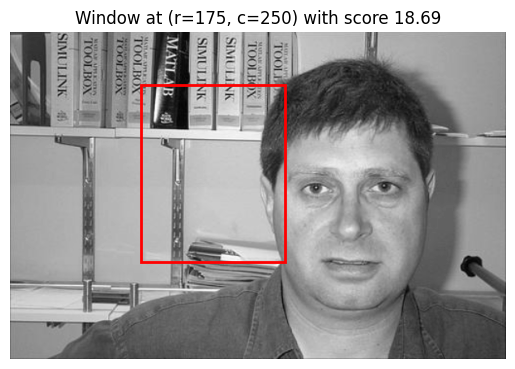

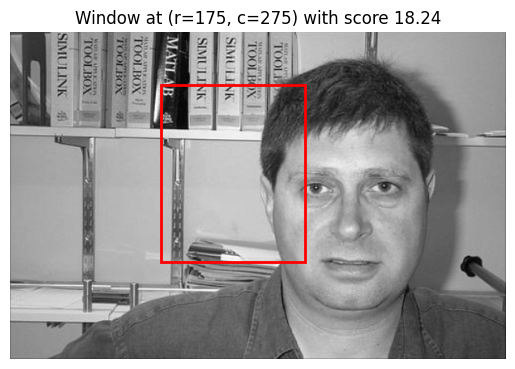

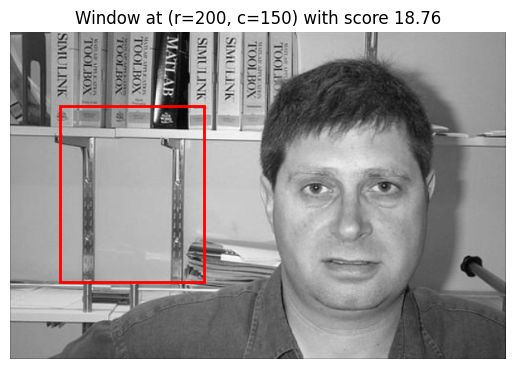

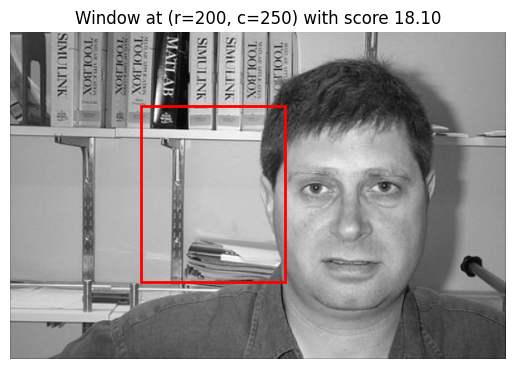

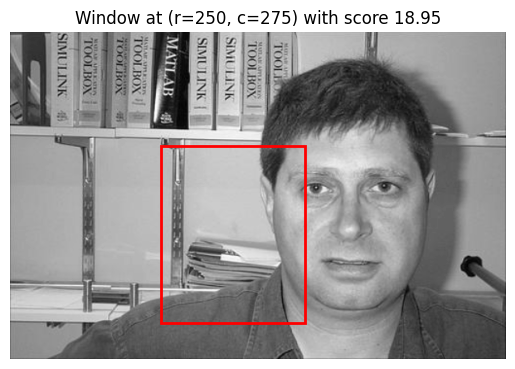

In [ ]:
from skimage.transform import rescale

scale = 1.2

scaled_image = rescale(test_image, scale, anti_aliasing=True)

step_size = 25
max_score, maxr, maxc, response_map_resized = sliding_window(
        scaled_image,
        template_feature,
        step_size,
        window_size,
        pixel_per_cell=8,
        debug=True,
        debug_score=18,
    )

Maximum score: 18.95102805958643
Location of max score (row, col): 250 275


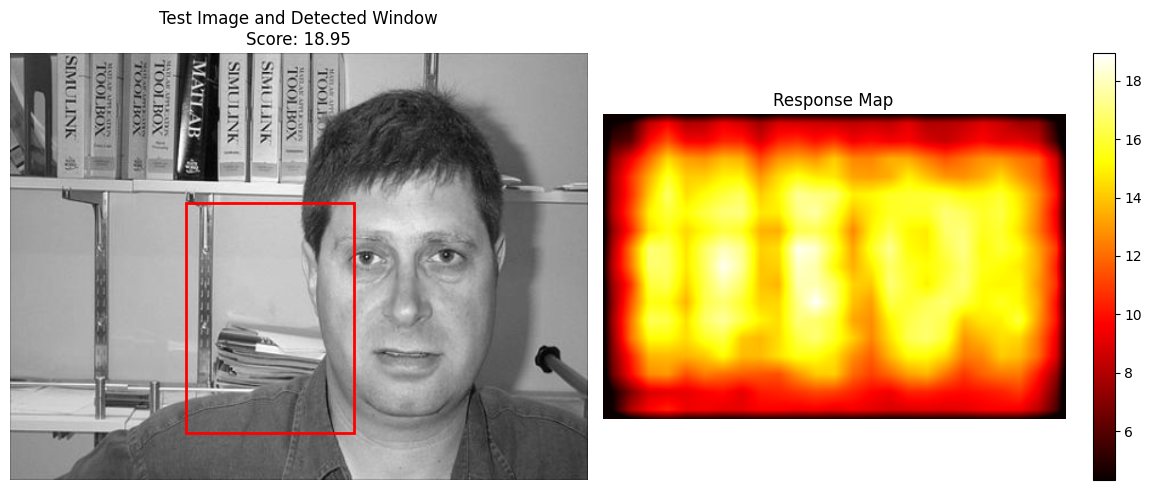

In [166]:
print("Maximum score:", max_score)
print("Location of max score (row, col):", maxr, maxc)
rect = patches.Rectangle((maxc - (window_size[1]) / 2, maxr - (window_size[0] ) / 2),
                          window_size[1], window_size[0],
                          edgecolor='red', facecolor='none', linewidth=2)

# Visualize the scaled image and the corresponding resized response map.
plt.figure(figsize=(12, 5)) 

# Plot the scaled image and add the rectangle to it.
ax = plt.subplot(1, 2, 1)
plt.imshow(scaled_image, cmap='gray', aspect='auto')
ax.add_patch(rect)  # Add the rectangle patch.
plt.title(f"Test Image and Detected Window\nScore: {max_score:.2f}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(response_map_resized, cmap='hot')
plt.title("Response Map")
plt.colorbar()
plt.axis("off")

plt.tight_layout()
plt.show()


Que remarquez-vous ?

When testing the sliding window detector with different image scales, we made three primary observations:

1. **Scale 0.8**  
   At this scale, the image is effectively zoomed out. The face in the test image appears smaller and farther from the camera, which better matches the average (mean) face we used as a template. Since our training set images were not particularly close-up shots, downscaling the test image to 0.8 causes the face to align more closely with the proportions in our mean face. As a result, the sliding window successfully focuses on the correct region and achieves a higher score where the actual face is located.

2. **Scale 1.0**  
   At the original scale, the face in the test image is somewhat larger relative to the mean face. Consequently, the window often detects random regions (like books or background) with higher scores than the actual face. This discrepancy happens because the face in the test image doesn’t match well (in size and proportions) with the averaged template face.

3. **Scale 1.2**  
   When upscaling the image, the face appears even closer and larger. Given that our template represents faces at a “normal” distance, the sliding window struggles to find a strong match in these zoomed-in patches. This results in generally lower scores on the face itself.

**Conclusion**

From these experiments, we see that scaling plays a significant role in the detector’s performance. In this specific scenario—where the training set faces are not too close to the camera—scaling the image down to 0.8 yields better alignment with the template, thus leading to higher detection scores on the actual face. Conversely, zooming in at 1.2 overshoots the template scale and prevents an effective match. Therefore, **choosing the right scale (or combination of scales) is crucial** for robust face detection when using a fixed-size sliding window and a mean face model.


### Utilisation d'une pyramide d'images.

Pour que la fenêtre glissante fonctionne à différentes échelles d'images, vous devez mettre en œuvre des pyramides d'images où vous redimensionnez l'image à différentes échelles et exécutez la méthode de la fenêtre glissante sur chaque image redimensionnée. De cette façon, vous mettez les objets à l'échelle et pouvez détecter aussi bien les petits que les grands objets. 

Compléter la fonction `pyramid` ci-dessous.


In [ ]:
def pyramid(image, scale=0.9, min_size=(100, 200)):
    """
    Generate an image pyramid using the given image and scale.
    Reducing the size of the image until either the height or
    width is below the minimum limit. In the ith iteration,
    the image is resized to scale^i of the original image.

    Args:
        image: np.array of shape (h, w), an image to scale.
        scale: float, the factor by which to rescale the image each time.
        min_size: tuple of ints (min_height, min_width); termination condition

    Returns:
        images: a list of tuples containing (current_scale, resized_image).
    """
    images = []
    
    # Start with the original image (scale factor = 1.0)
    current_scale = 1.0
    images.append((current_scale, image))
    
    while True:
        # Compute new dimensions for the image using the scale factor.
        new_h = int(image.shape[0] * scale)
        new_w = int(image.shape[1] * scale)
        
        # stop if the resized image is smaller than min_size.
        if new_h < min_size[0] or new_w < min_size[1]:
            break
        
        # Resize the image to new dimensions.
        image = resize(image, (new_h, new_w), anti_aliasing=True)
        
        # Update the cumulative scale factor.
        current_scale *= scale
        
        images.append((current_scale, image))
    
    return images


Tester votre fonction

Original image shape: (337, 510)
Number of pyramid levels: 5


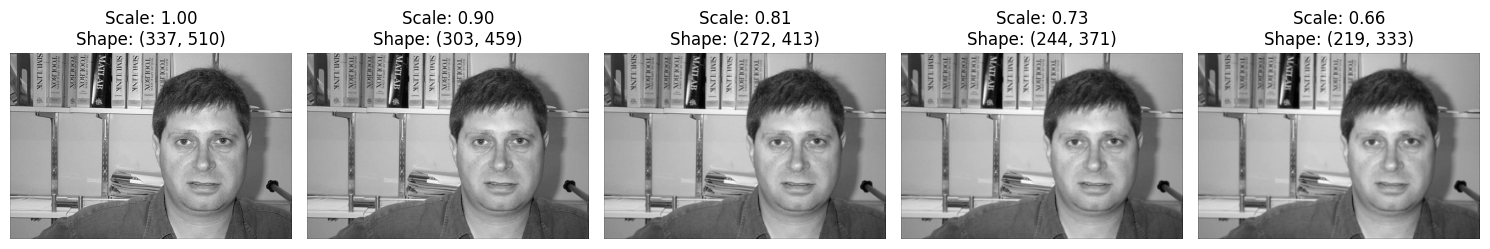

In [170]:
import matplotlib.pyplot as plt
from skimage import data
import numpy as np
 
print("Original image shape:", test_image.shape)

# Generate the image pyramid.
pyramid_levels = pyramid(test_image, scale=0.9, min_size=(218, 178))
print("Number of pyramid levels:", len(pyramid_levels))

# Plot each level of the pyramid.
fig, axes = plt.subplots(1, len(pyramid_levels), figsize=(15, 5))
for ax, (scale_factor, img) in zip(axes, pyramid_levels):
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Scale: {scale_factor:.2f}\nShape: {img.shape}")
    ax.axis('off')

plt.tight_layout()
plt.show()


### Détection avec la pyramide

Après avoir obtenu la pyramide d'images, nous allons exécuter la fenêtre glissante sur toutes les images pour trouver un endroit qui obtient le score le plus élevé. Implémentez la fonction **`pyramid_score`**. Elle retournera le score le plus élevé et ses informations dans les pyramides d'images.

In [190]:
def pyramid_score(image, template_feature, shape, step_size=20,
                  scale=0.9, pixel_per_cell=8, debug=False, debug_score=21):
    """
    Calculate the maximum score found in the image pyramid using sliding window.
    
    Args:
        image: np.array of shape (h, w).
        template_feature: the HOG feature vector of the object you want to detect.
        shape: tuple (height, width) for the window size to use with the sliding window.
        step_size: int, step size for moving the sliding window.
        scale: float, scale factor for the image pyramid.
        pixel_per_cell: int, parameter for HOG extraction.
    
    Returns:
        max_score: float, the highest HOG score found.
        maxr: int, row coordinate (in the original image) where the max score is found.
        maxc: int, column coordinate (in the original image) where the max score is found.
        max_scale: float, the pyramid scale at which the max score was found.
        max_response_map: np.array, the response map (resized to the scaled image dimensions)
                          corresponding to the maximum score.
    """
    # Initialize global results.
    max_score = -np.inf
    maxr = 0
    maxc = 0
    max_scale = 1.0
    max_response_map = None

    # Generate the image pyramid.
    images = pyramid(image, scale)
    
    
    
    # Iterate through each level of the pyramid.
    for current_scale, scaled_image in images: 
        level_max_score, level_maxr, level_maxc, level_response_map_resized = sliding_window(
            image=scaled_image,
            template_feature=template_feature,
            step_size=step_size,
            window_size=shape,
            return_unresized_response=False,
            debug=debug,
            debug_score=debug_score,
        )
        


        # Update global maximum if this level's max score is higher.
        if level_max_score > max_score:
            max_score = level_max_score
            max_scale = current_scale
            # Convert the window coordinates from the scaled image back to original image coordinates.
            maxr = int(level_maxr / current_scale)
            maxc = int(level_maxc / current_scale)
            max_response_map = level_response_map_resized

    return max_score, maxr, maxc, max_scale, max_response_map


Tester votre fonction sur l'image ci-dessous?

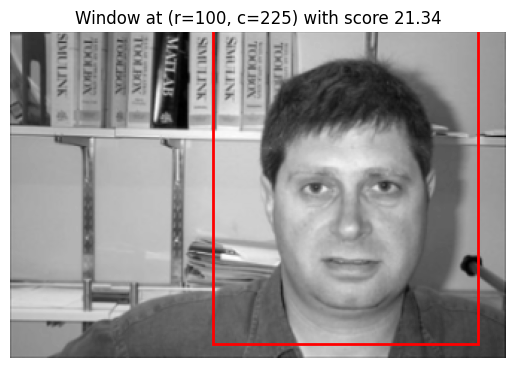

In [ ]:
image_path = 'image_0001.jpg'
test_image = io.imread(image_path)

# Convert the test image to grayscale
if test_image.ndim == 3:
    test_image = color.rgb2gray(test_image)

window_size = (218, 178) 
step_size = 25            
scale_factor = 0.9        

# Call pyramid_score to search for the best matching window across the image pyramid.
max_score, maxr, maxc, max_scale, max_response_map = pyramid_score(
    test_image,
    template_feature,
    shape=window_size,
    step_size=step_size,
    scale=scale_factor,
    pixel_per_cell=8,
    debug=True,
    debug_score=21
)



Maximum HOG Score: 21.336350341899273
Location of max score (row, col): 152 342
Scale factor where max score was found: 0.6561000000000001


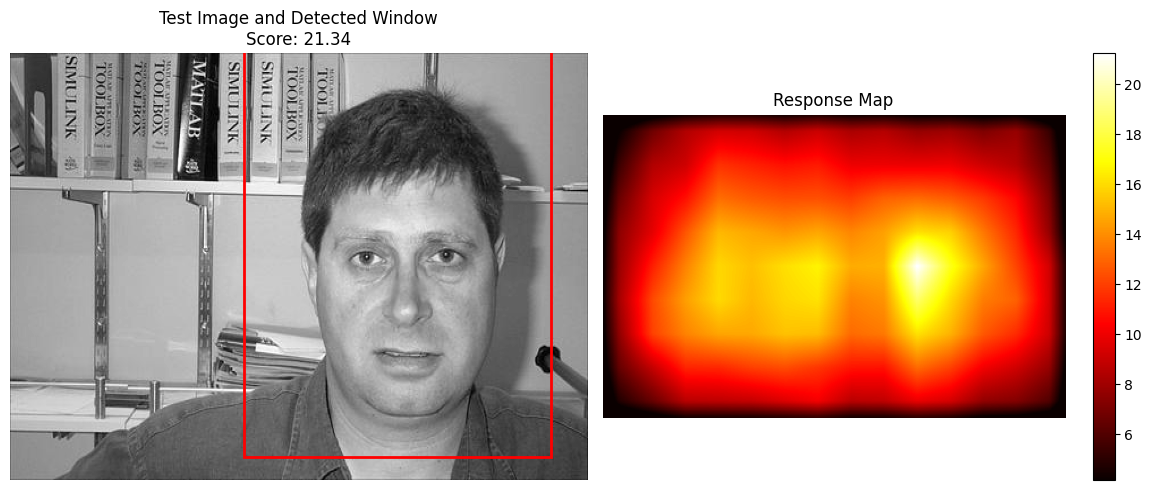

In [ ]:
print("Maximum HOG Score:", max_score)
print("Location of max score (row, col):", maxr, maxc)
print("Scale factor where max score was found:", max_scale)

scaled_max_image = rescale(test_image, max_scale, anti_aliasing=True)

scaled_window_size = (int(window_size[0] / max_scale), int(window_size[1] / max_scale))

rect = patches.Rectangle((maxc - (scaled_window_size[1]) / 2, maxr - (scaled_window_size[0] ) / 2),
                          scaled_window_size[1], scaled_window_size[0],
                          edgecolor='red', facecolor='none', linewidth=2)


plt.figure(figsize=(12, 5)) 


ax = plt.subplot(1, 2, 1)
plt.imshow(test_image, cmap='gray', aspect='auto')
ax.add_patch(rect)
plt.title(f"Test Image and Detected Window\nScore: {max_score:.2f}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(max_response_map, cmap='hot')
plt.title("Response Map")
plt.colorbar()
plt.axis("off")

plt.tight_layout()
plt.show()


After implementing the pyramid approach, we observed a significant improvement in face detection performance. Here are the key points:

1. **Best Scale and Score**  
   - By analyzing multiple scales, we found that **scale 0.6** produced the highest detection score (**21.34** in the example), surpassing the results obtained when using a single scale (or the original size).
   - This confirms that scaling the image so the face better matches the template (mean face) can dramatically boost the detection score.

2. **Improved Response Map**  
   - At the optimal scale, the **response map** is more peaked around the true face location. This indicates a stronger alignment between the face in the scaled image and the HOG features in the mean face template.
   - Visually inspecting the heat map shows that the region around the actual face yields distinctly higher scores compared to other areas.


**Summary and Outlook**  
   - The pyramid approach allows us to systematically try different image sizes to handle variations in object (or face) size. 
   - In a real-world scenario, faces (or objects) can appear closer or farther from the camera, making them seem larger or smaller. By using a range of scales, the detector is better equipped to locate both smaller and larger instances of the same object within the image.
   - Multi-scale detection (via image pyramids) proves essential for reliable performance in object detection tasks. The face detection example illustrates that when the single-scale approach fails to align well with the target face, exploring additional scales helps overcome the mismatch.
   - In practice, we might tune the scale range (e.g., from 0.5 to 1.5) and step sizes (e.g., 0.1 increments) to handle an even wider variety of object sizes.

Overall, **the pyramid approach significantly improves our chance of matching the template** with real-world images where the object’s scale can vary. This enables more robust and accurate face detection, as evidenced by the higher scores and clearer response maps.
